In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

In [2]:
df = pd.read_csv('/content/bank_fraud.csv')

In [3]:
df

,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,...,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type
0,TXN0000000001,CUST00121959,2023-08-17,21:13:00,21.0,0.0,0.0,USA,London,Grocery,...,39.49,157.0,23.0,52.7,10.20,0.0,0.0,0.0,0.0,NaN
1,TXN0000000002,CUST00146868,2024-02-06,05:16:00,5.0,0.0,1.0,UK,New York,Healthcare,...,153.71,153.0,23.0,0.9,12.47,0.0,0.0,0.0,0.0,NaN
2,TXN0000000003,CUST00131933,2024-06-28,12:15:00,12.0,0.0,0.0,Canada,Delhi,Grocery,...,118.20,161.0,20.0,9.2,0.08,0.0,1.0,0.0,0.0,NaN
3,TXN0000000004,CUST00103695,2023-03-16,02:53:00,2.0,0.0,1.0,France,Tokyo,Utilities,...,49.50,160.0,25.0,14.8,17.94,1.0,0.0,1.0,1.0,Synthetic Identity
4,TXN0000000005,CUST00119880,2024-07-12,12:39:00,12.0,0.0,0.0,Canada,Melbourne,Clothing,...,30.74,134.0,18.0,38.9,2.16,0.0,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54528,TXN0000054529,CUST00158088,2022-03-21,01:09:00,1.0,0.0,1.0,USA,Manchester,Online Shopping,...,17.88,136.0,22.0,33.7,19.22,0.0,0.0,0.0,0.0,NaN
54529,TXN0000054530,CUST00080225,2023-01-26,20:56:00,20.0,0.0,0.0,Mexico,Manchester,Entertainment,...,86.74,154.0,16.0,12.4,10.51,0.0,0.0,0.0,0.0,NaN
54530,TXN0000054531,CUST00014351,2024-11-26,18:21:00,18.0,0.0,0.0,India,Tokyo,Grocery,...,106.31,144.0,13.0,20.6,18.98,0.0,0.0,0.0,0.0,NaN
54531,TXN0000054532,CUST00104753,2020-05-10,07:15:00,7.0,1.0,0.0,USA,Mexico City,Utilities,...,58.58,165.0,25.0,20.8,20.94,0.0,0.0,0.0,0.0,NaN


In [4]:
df.shape

(54533, 26)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54533 entries, 0 to 54532
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   transaction_id            54533 non-null  object 
 1   customer_id               54532 non-null  object 
 2   transaction_date          54532 non-null  object 
 3   transaction_time          54532 non-null  object 
 4   hour_of_day               54532 non-null  float64
 5   is_weekend                54532 non-null  float64
 6   is_night_transaction      54532 non-null  float64
 7   country                   54532 non-null  object 
 8   city                      54532 non-null  object 
 9   merchant_category         54532 non-null  object 
 10  payment_method            54532 non-null  object 
 11  device_type               54532 non-null  object 
 12  customer_age              54532 non-null  float64
 13  credit_score              54532 non-null  float64
 14  accoun

In [6]:
df.describe()

,hour_of_day,is_weekend,is_night_transaction,customer_age,credit_score,account_age_years,account_balance,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud
count,54532.000000,54532.000000,54532.000000,54532.000000,54532.000000,54532.000000,54532.000000,54532.000000,54532.000000,54532.000000,54532.000000,54532.00000,54532.000000,54532.000000,54532.000000,54532.000000
mean,11.488649,0.288051,0.375119,41.729150,679.415866,4.927140,16723.104906,206.129835,149.966350,19.996864,20.013629,12.04495,0.149655,0.386654,0.079220,0.056004
std,6.932659,0.452859,0.484158,13.412633,78.935768,4.852044,28637.754332,487.348683,12.245049,4.463908,19.828610,12.00869,0.356736,0.921209,0.270084,0.229931
min,0.000000,0.000000,0.000000,18.000000,351.000000,0.100000,100.000000,1.000000,100.000000,3.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,0.000000,0.000000,32.000000,626.000000,1.400000,3587.910000,33.250000,142.000000,17.000000,5.800000,3.48000,0.000000,0.000000,0.000000,0.000000
50%,11.000000,0.000000,0.000000,41.000000,679.000000,3.400000,8083.345000,72.810000,150.000000,20.000000,14.000000,8.40000,0.000000,0.000000,0.000000,0.000000
75%,18.000000,1.000000,1.000000,51.000000,734.000000,6.800000,18412.072500,182.412500,158.000000,23.000000,27.900000,16.73250,0.000000,0.000000,0.000000,0.000000
max,23.000000,1.000000,1.000000,85.000000,850.000000,30.000000,500000.000000,32014.830000,202.000000,39.000000,262.900000,121.64000,1.000000,5.000000,1.000000,1.000000


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

,0
transaction_id,0
customer_id,1
transaction_date,1
transaction_time,1
hour_of_day,1
is_weekend,1
is_night_transaction,1
country,1
city,1
merchant_category,1


In [9]:
target_counts = df['is_fraud'].value_counts()
target_pct = df['is_fraud'].value_counts(normalize=True) * 100

print(f'Legitimate (0): {target_counts[0]:>10,} ({target_pct[0]:.2f}%)')
print(f'Fraud (1): {target_counts[1]:>10,} ({target_pct[1]:.2f}%)')
print(f'Imbalance ratio: {target_counts[0]/target_counts[1]:.1f}:1')

Legitimate (0):     51,478 (94.40%)
Fraud (1):      3,054 (5.60%)
Imbalance ratio: 16.9:1


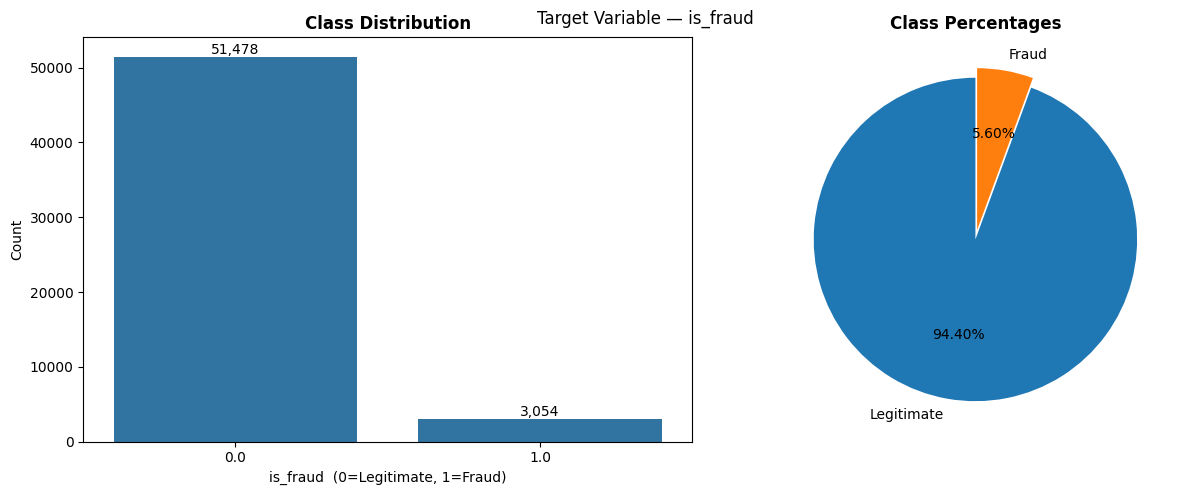

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(x='is_fraud', data=df, ax=axes[0])
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_xlabel('is_fraud  (0=Legitimate, 1=Fraud)')
axes[0].set_ylabel('Count')
for bar in axes[0].patches:
    axes[0].annotate(f'{bar.get_height():,.0f}',
                     (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=10)

sizes = [target_counts[0], target_counts[1]]
labels = ['Legitimate', 'Fraud']

axes[1].pie(sizes, labels=labels, autopct='%1.2f%%', startangle=90, explode=(0, 0.06))
axes[1].set_title('Class Percentages', fontweight='bold')

plt.tight_layout()
plt.suptitle('Target Variable — is_fraud')
plt.show()

fraud_type
Friendly Fraud        547
Card Cloning          528
Phishing              513
Identity Theft        493
Account Takeover      488
Synthetic Identity    485
Name: count, dtype: int64


/tmp/ipykernel_2366/1744634882.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_type_counts.values, y=fraud_type_counts.index,


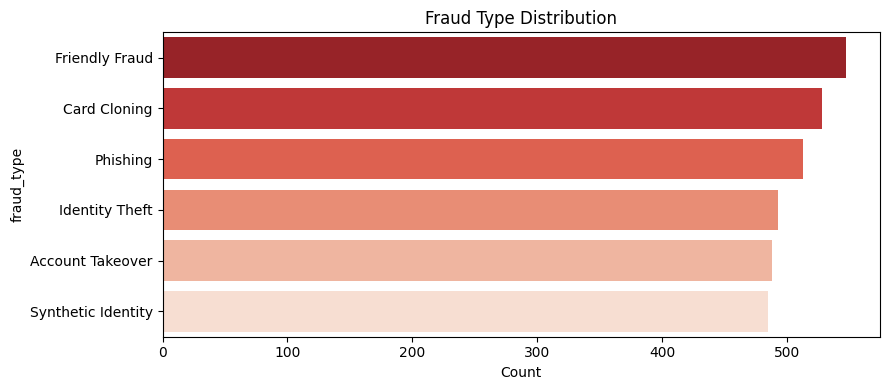

In [11]:
fraud_only = df[df['is_fraud'] == 1]
print(fraud_only['fraud_type'].value_counts())

plt.figure(figsize=(9, 4))
fraud_type_counts = fraud_only['fraud_type'].value_counts()
sns.barplot(x=fraud_type_counts.values, y=fraud_type_counts.index,
            palette='Reds_r')
plt.title('Fraud Type Distribution')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

In [12]:
df.drop(['transaction_id', 'customer_id', 'fraud_type'], axis = 1, inplace = True)

In [13]:
df

,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,payment_method,device_type,...,account_balance,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud
0,2023-08-17,21:13:00,21.0,0.0,0.0,USA,London,Grocery,Bank Transfer,POS Terminal,...,369.36,39.49,157.0,23.0,52.7,10.20,0.0,0.0,0.0,0.0
1,2024-02-06,05:16:00,5.0,0.0,1.0,UK,New York,Healthcare,Cheque,Desktop,...,2681.99,153.71,153.0,23.0,0.9,12.47,0.0,0.0,0.0,0.0
2,2024-06-28,12:15:00,12.0,0.0,0.0,Canada,Delhi,Grocery,Crypto,Mobile,...,44590.64,118.20,161.0,20.0,9.2,0.08,0.0,1.0,0.0,0.0
3,2023-03-16,02:53:00,2.0,0.0,1.0,France,Tokyo,Utilities,Debit Card,Mobile,...,1213.37,49.50,160.0,25.0,14.8,17.94,1.0,0.0,1.0,1.0
4,2024-07-12,12:39:00,12.0,0.0,0.0,Canada,Melbourne,Clothing,Debit Card,Desktop,...,34615.01,30.74,134.0,18.0,38.9,2.16,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54528,2022-03-21,01:09:00,1.0,0.0,1.0,USA,Manchester,Online Shopping,Credit Card,POS Terminal,...,18069.75,17.88,136.0,22.0,33.7,19.22,0.0,0.0,0.0,0.0
54529,2023-01-26,20:56:00,20.0,0.0,0.0,Mexico,Manchester,Entertainment,Debit Card,Mobile,...,3459.34,86.74,154.0,16.0,12.4,10.51,0.0,0.0,0.0,0.0
54530,2024-11-26,18:21:00,18.0,0.0,0.0,India,Tokyo,Grocery,Debit Card,Mobile,...,3649.19,106.31,144.0,13.0,20.6,18.98,0.0,0.0,0.0,0.0
54531,2020-05-10,07:15:00,7.0,1.0,0.0,USA,Mexico City,Utilities,Bank Transfer,Mobile,...,32596.82,58.58,165.0,25.0,20.8,20.94,0.0,0.0,0.0,0.0


In [14]:
date_cols = ['transaction_date', 'transaction_time']
date_cols

['transaction_date', 'transaction_time']

In [15]:
numeric_cols = df.select_dtypes(include= np.number).columns.drop('is_fraud').to_list()
binary_cols = [
    'is_weekend', 'is_night_transaction',
    'is_international', 'pin_changed_recently'
]
categorical_cols = df.select_dtypes(include='object').columns.tolist()

In [16]:
target = 'is_fraud'

In [17]:
df.isnull().sum()

,0
transaction_date,1
transaction_time,1
hour_of_day,1
is_weekend,1
is_night_transaction,1
country,1
city,1
merchant_category,1
payment_method,1
device_type,1


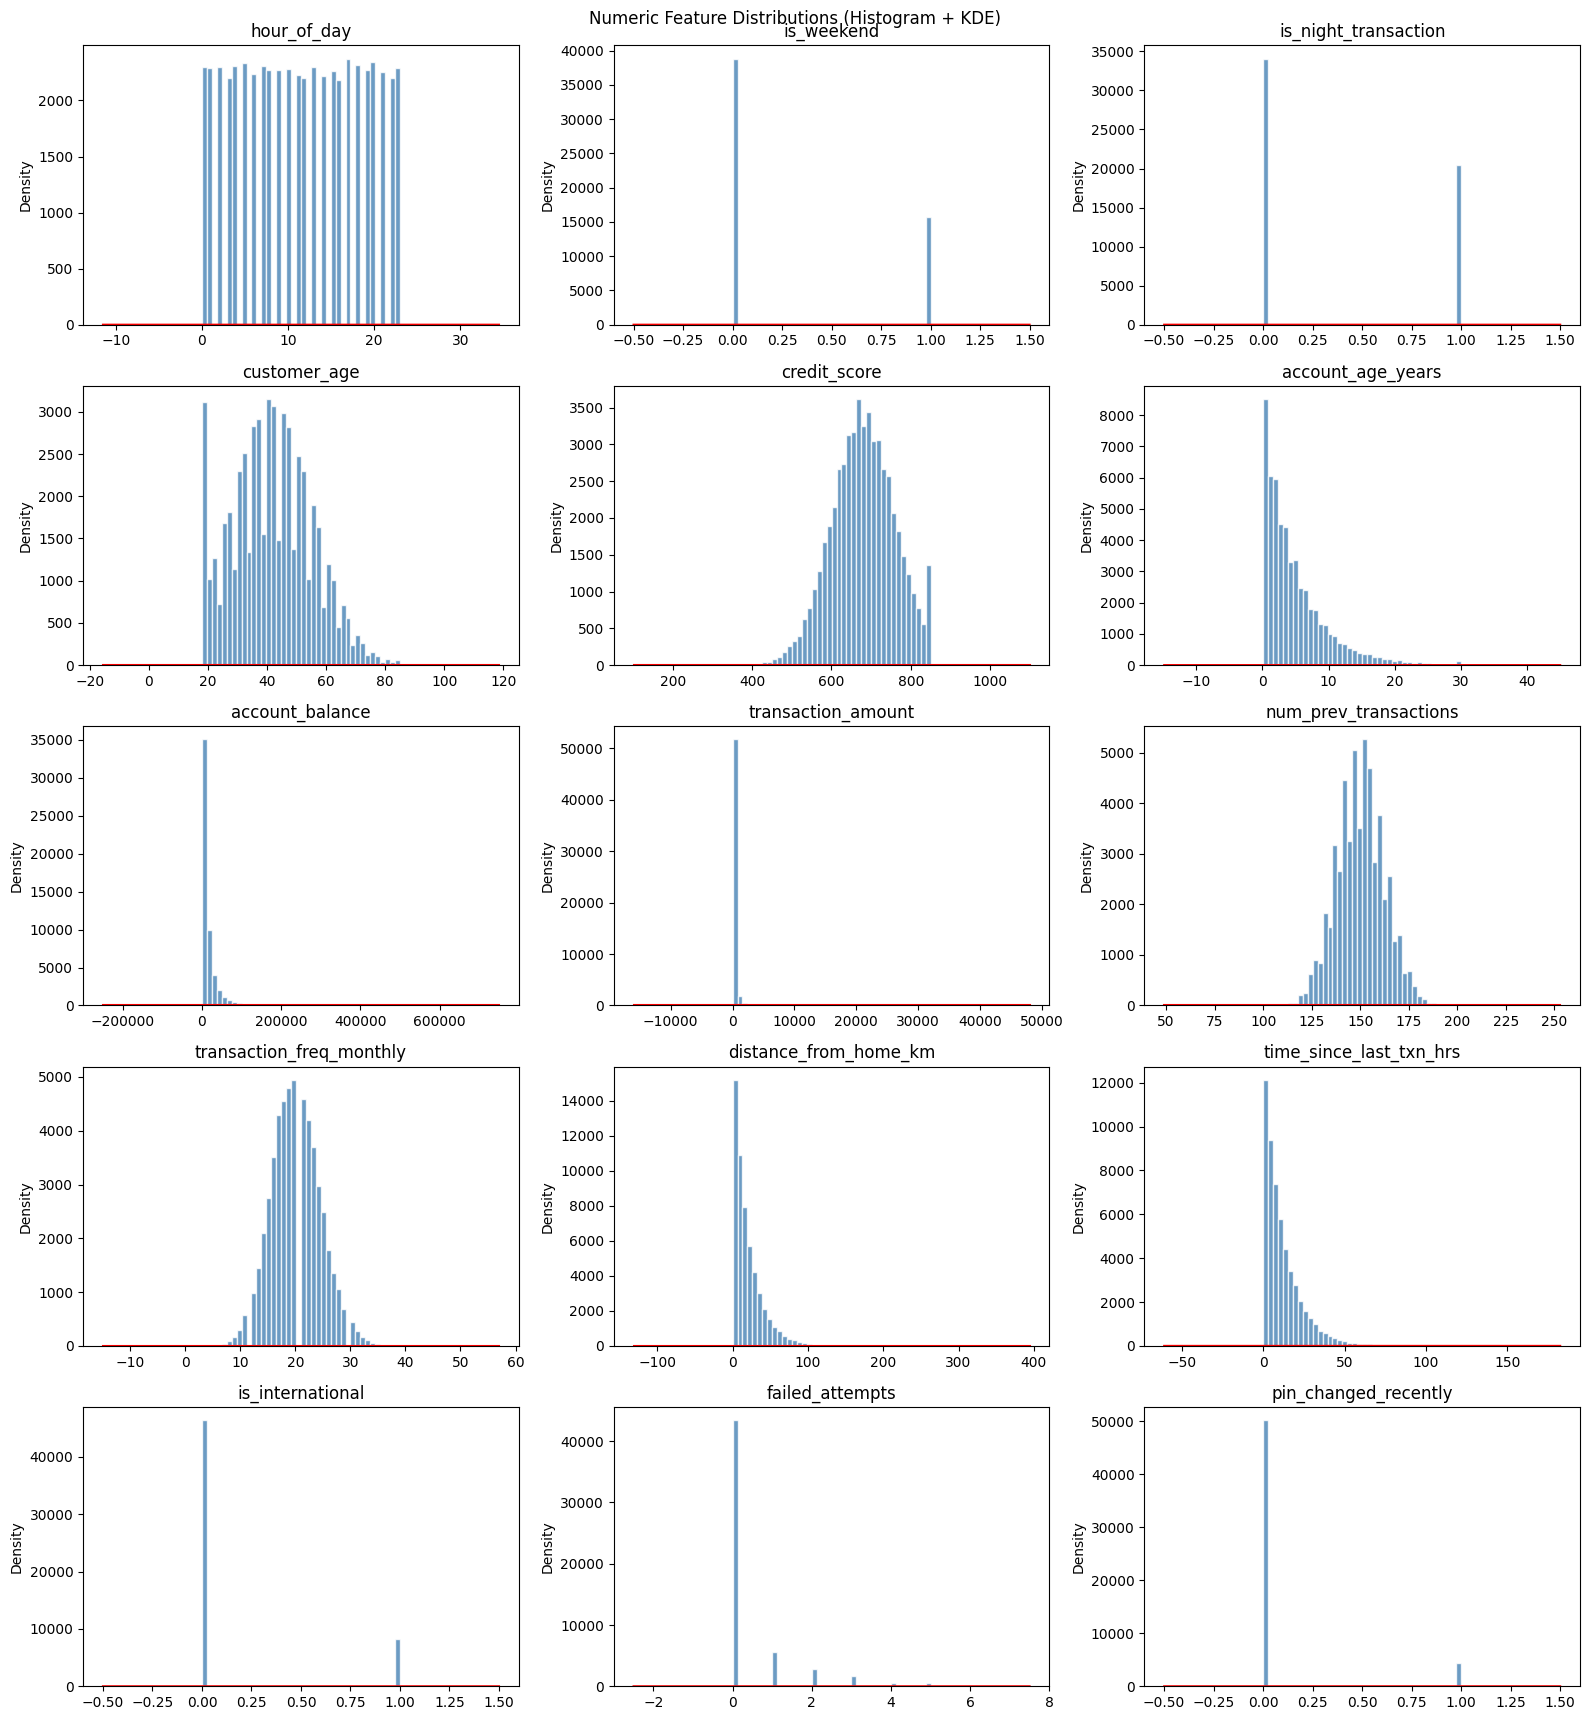

In [18]:
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if col in df.columns:
        df[col].plot(kind='hist', bins=40, ax=axes[i],
                     color='steelblue', edgecolor='white', alpha=0.8)
        df[col].plot(kind='kde', ax=axes[i], secondary_y=False,
                     color='red', linewidth=1.5)
        axes[i].set_title(col)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions (Histogram + KDE)')
plt.tight_layout()
plt.show()

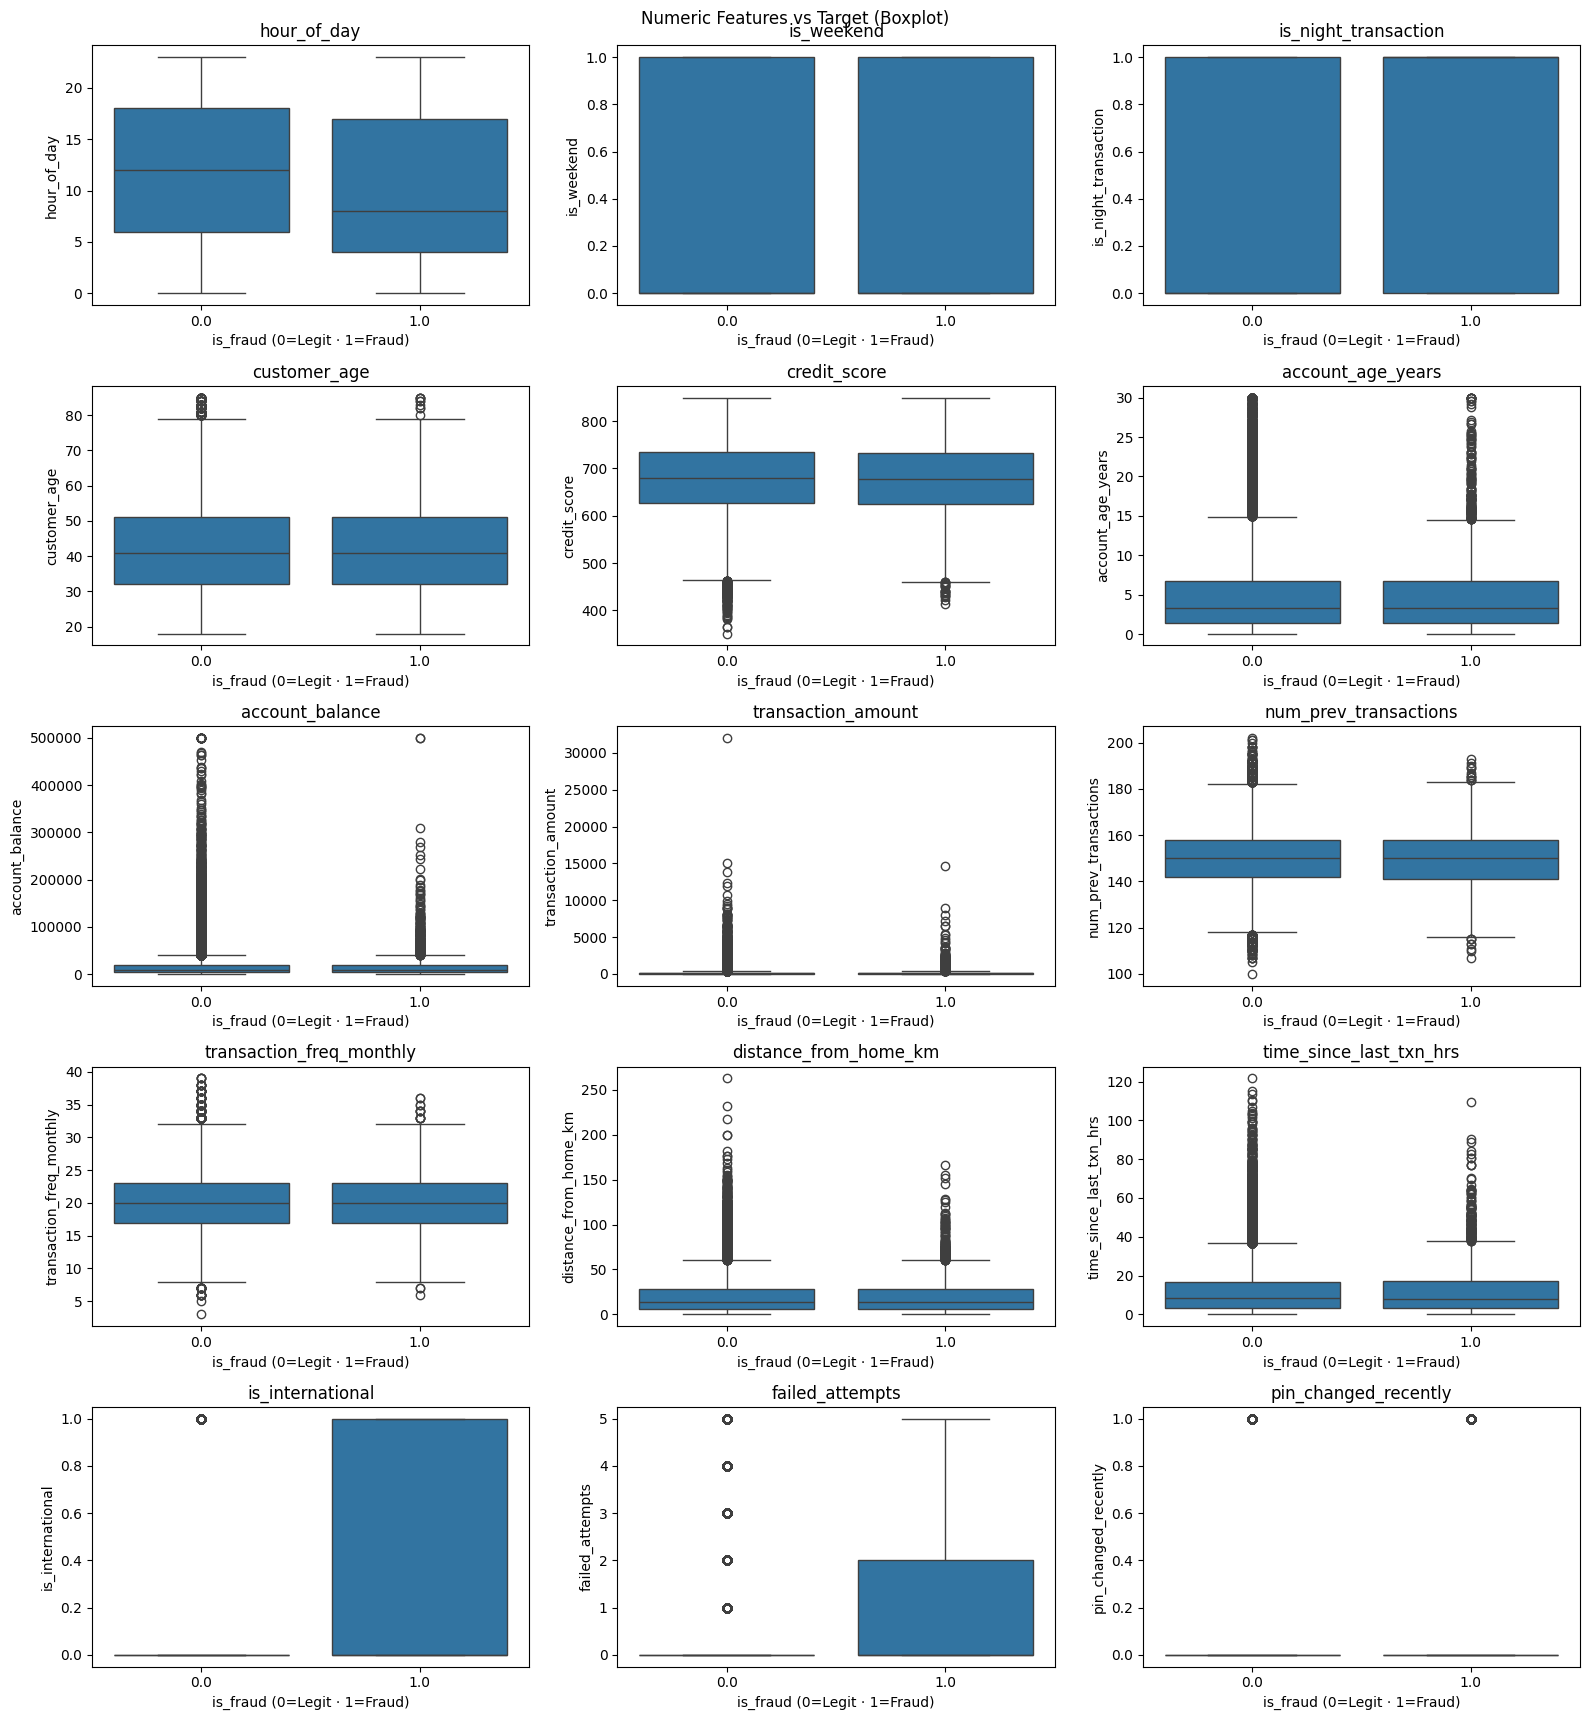

In [19]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if col in df.columns:
        sns.boxplot(x='is_fraud', y=col, data=df,
                    ax=axes[i])
        axes[i].set_title(col)
        axes[i].set_xlabel('is_fraud (0=Legit · 1=Fraud)')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Features vs Target (Boxplot)')
plt.tight_layout()
plt.show()

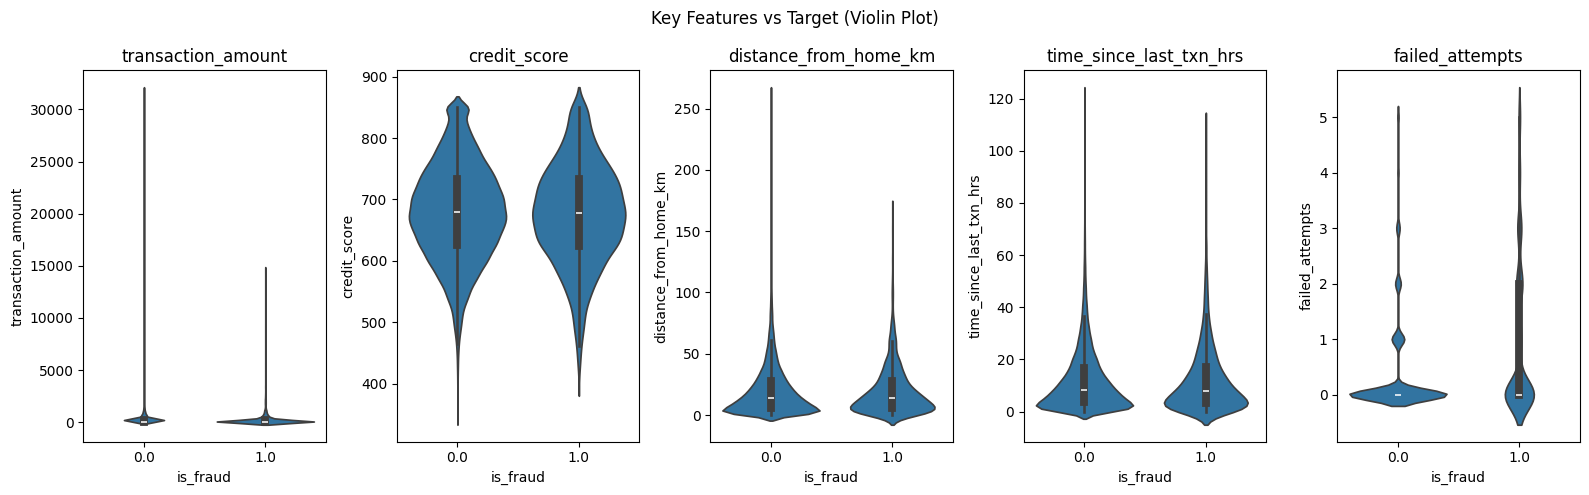

In [20]:
key_features = ['transaction_amount', 'credit_score', 'distance_from_home_km',
                'time_since_last_txn_hrs', 'failed_attempts']
key_features = [f for f in key_features if f in df.columns]

fig, axes = plt.subplots(1, len(key_features), figsize=(16, 5))
for i, col in enumerate(key_features):
    sns.violinplot(x='is_fraud', y=col, data=df, ax=axes[i], inner='box')
    axes[i].set_title(col)
    axes[i].set_xlabel('is_fraud')

plt.suptitle('Key Features vs Target (Violin Plot)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2366/2298713859.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=order,
/tmp/ipykernel_2366/2298713859.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=order,
/tmp/ipykernel_2366/2298713859.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=order,
/tmp/ipykernel_2366/2298713859.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the

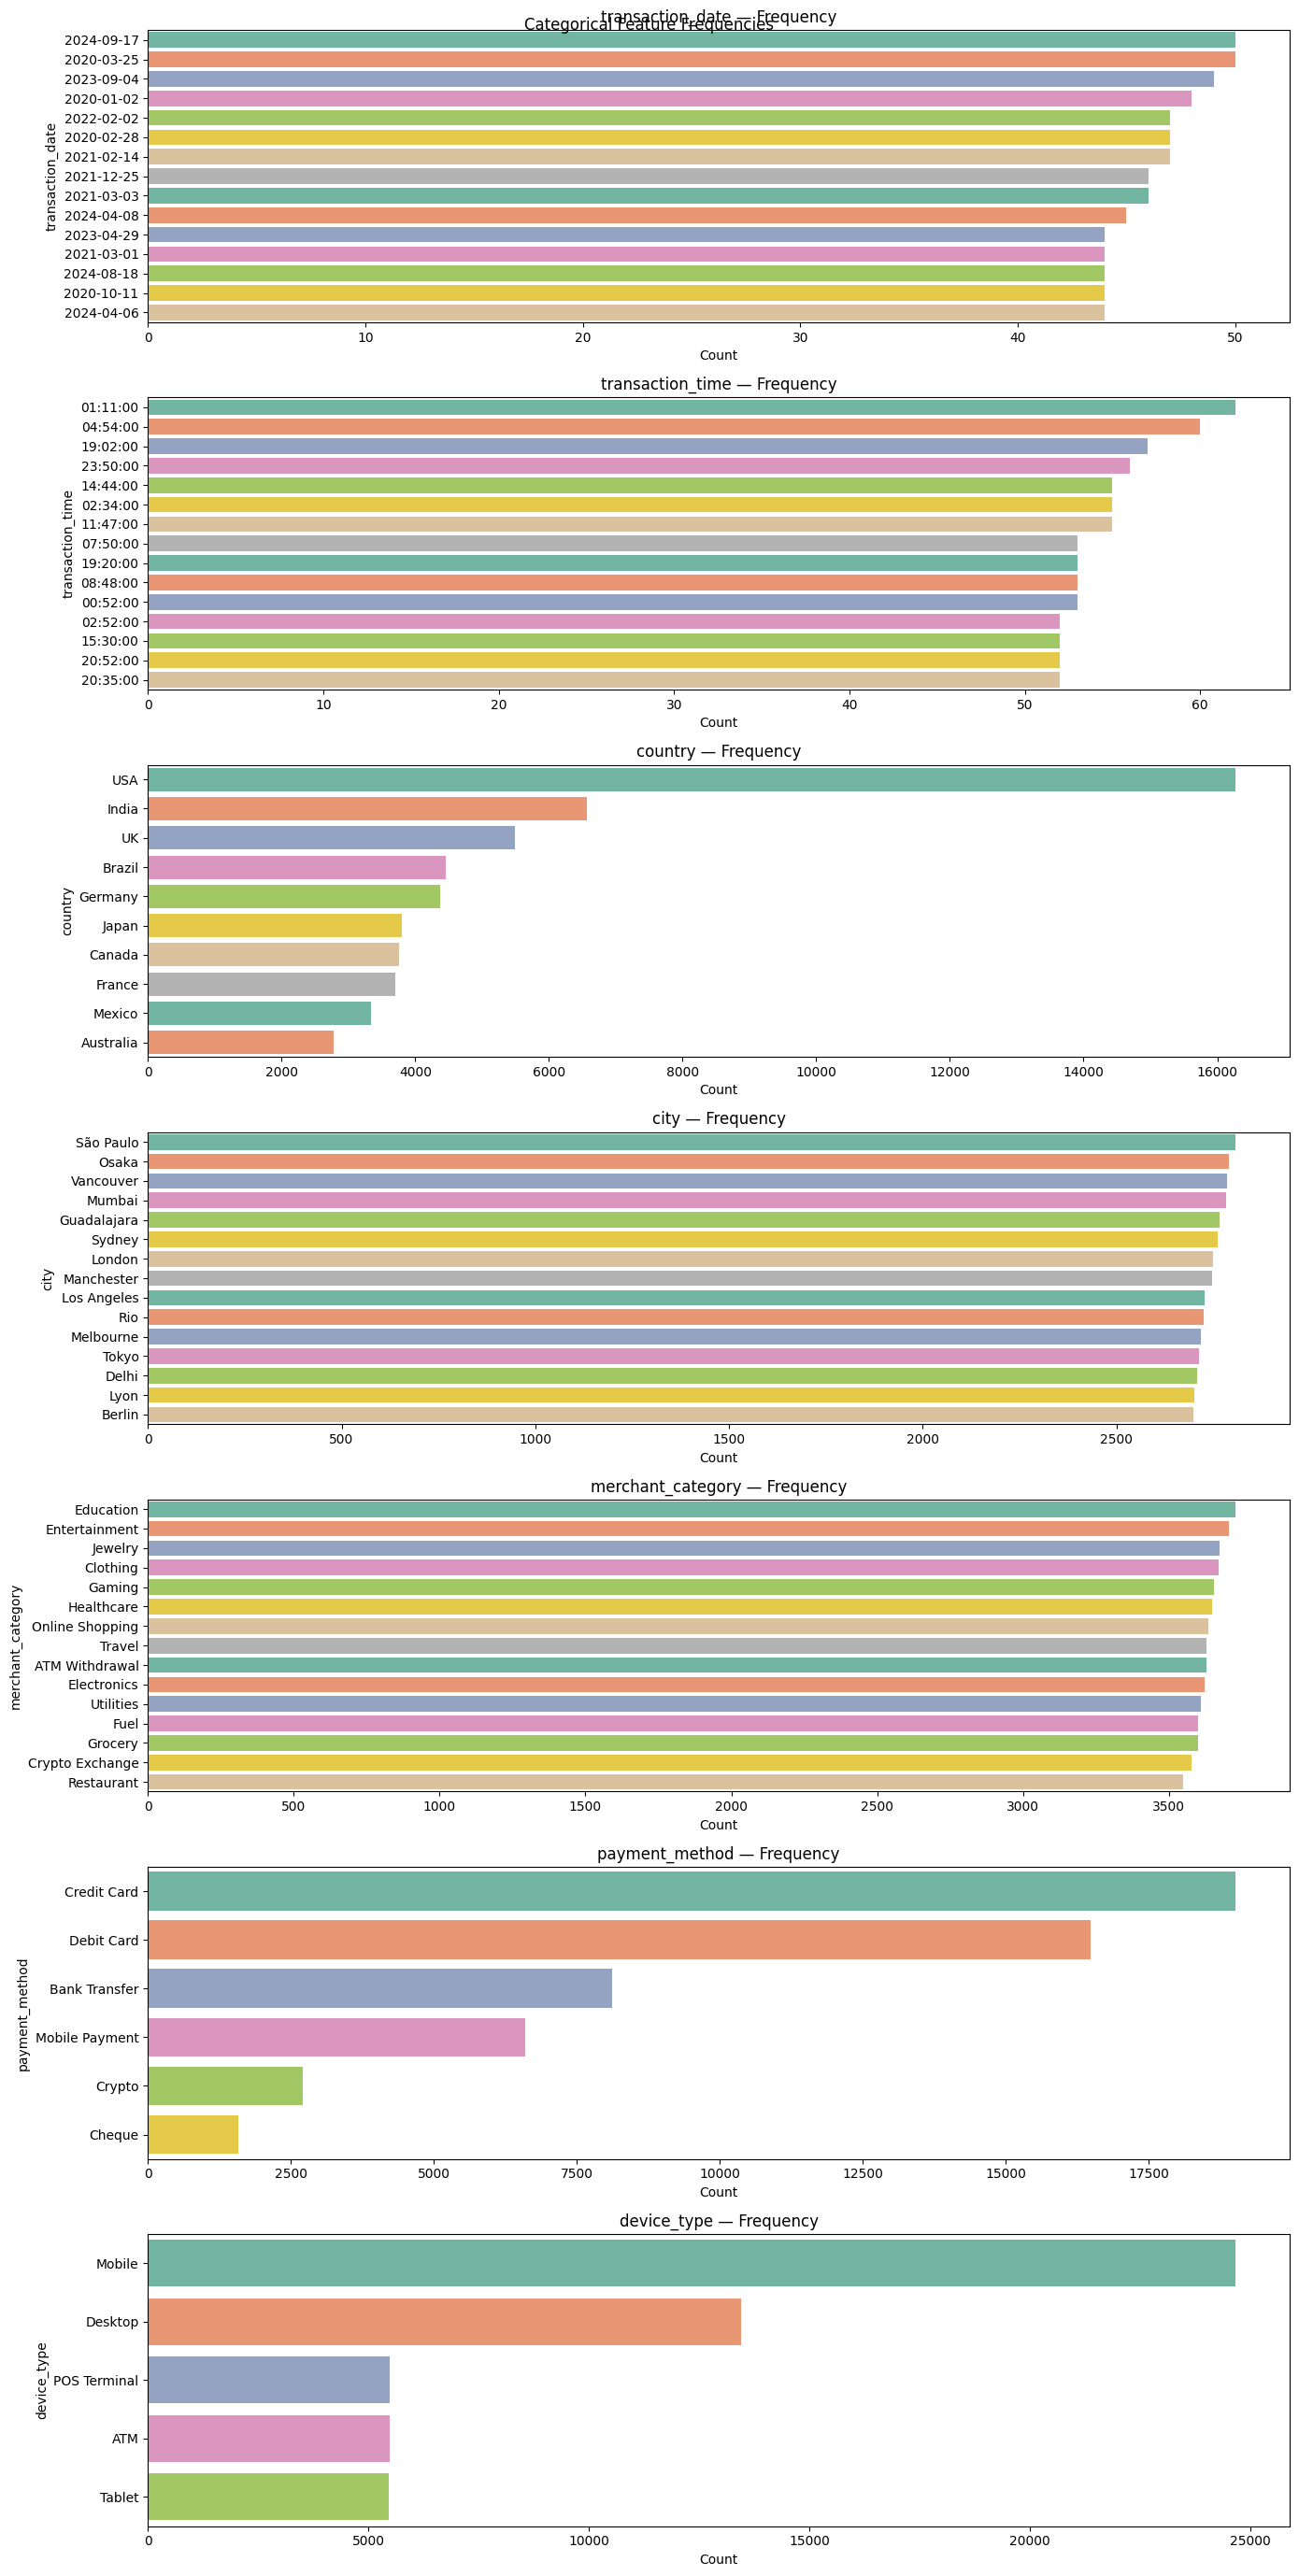

In [21]:
fig, axes = plt.subplots(len(categorical_cols), 1,
                          figsize=(14, 4 * len(categorical_cols)))

for i, col in enumerate(categorical_cols):
    if col in df.columns:
        order = df[col].value_counts().index[:15]
        sns.countplot(y=col, data=df, order=order,
                      palette='Set2', ax=axes[i])
        axes[i].set_title(f'{col} — Frequency')
        axes[i].set_xlabel('Count')

plt.suptitle('Categorical Feature Frequencies')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2366/933365961.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_rate.values, y=fraud_rate.index,
/tmp/ipykernel_2366/933365961.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_rate.values, y=fraud_rate.index,
/tmp/ipykernel_2366/933365961.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_rate.values, y=fraud_rate.index,
/tmp/ipykernel_2366/933365961.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and 

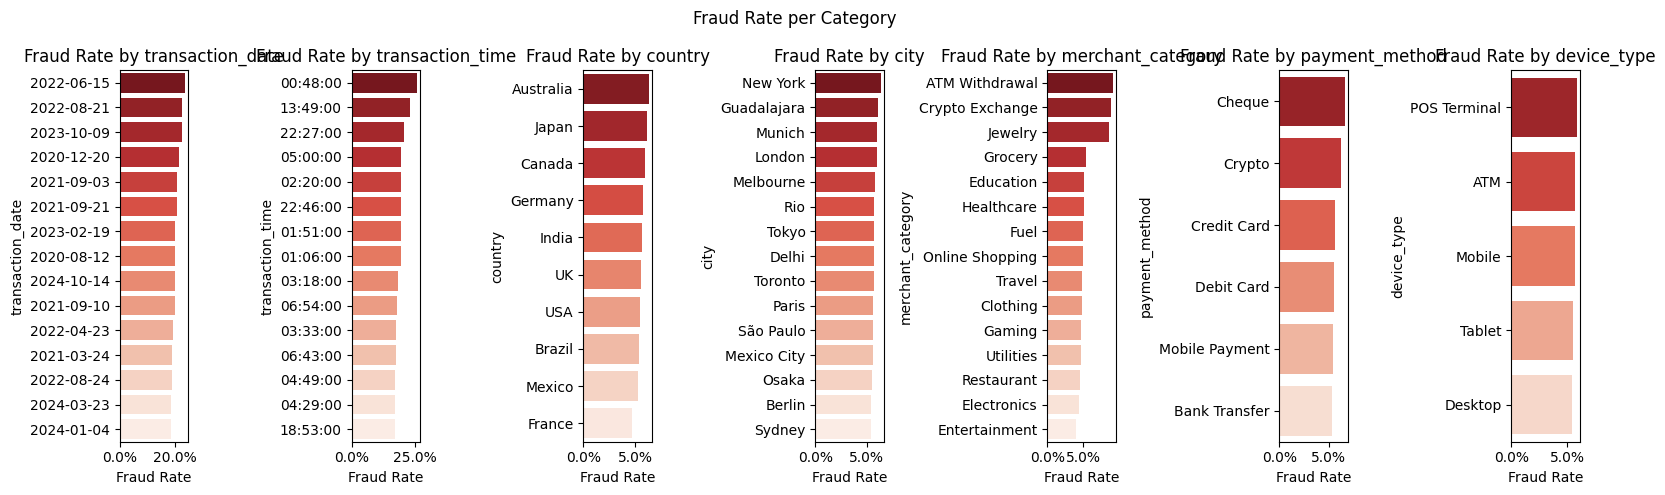

In [22]:
fig, axes = plt.subplots(1, len(categorical_cols),
                          figsize=(16, 5))

for i, col in enumerate(categorical_cols):
    if col in df.columns:
        fraud_rate = df.groupby(col)['is_fraud'].mean().sort_values(ascending=False)
        fraud_rate = fraud_rate.head(15)
        sns.barplot(x=fraud_rate.values, y=fraud_rate.index,
                    palette='Reds_r', ax=axes[i])
        axes[i].set_title(f'Fraud Rate by {col}')
        axes[i].set_xlabel('Fraud Rate')
        axes[i].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.suptitle('Fraud Rate per Category')
plt.tight_layout()
plt.show()

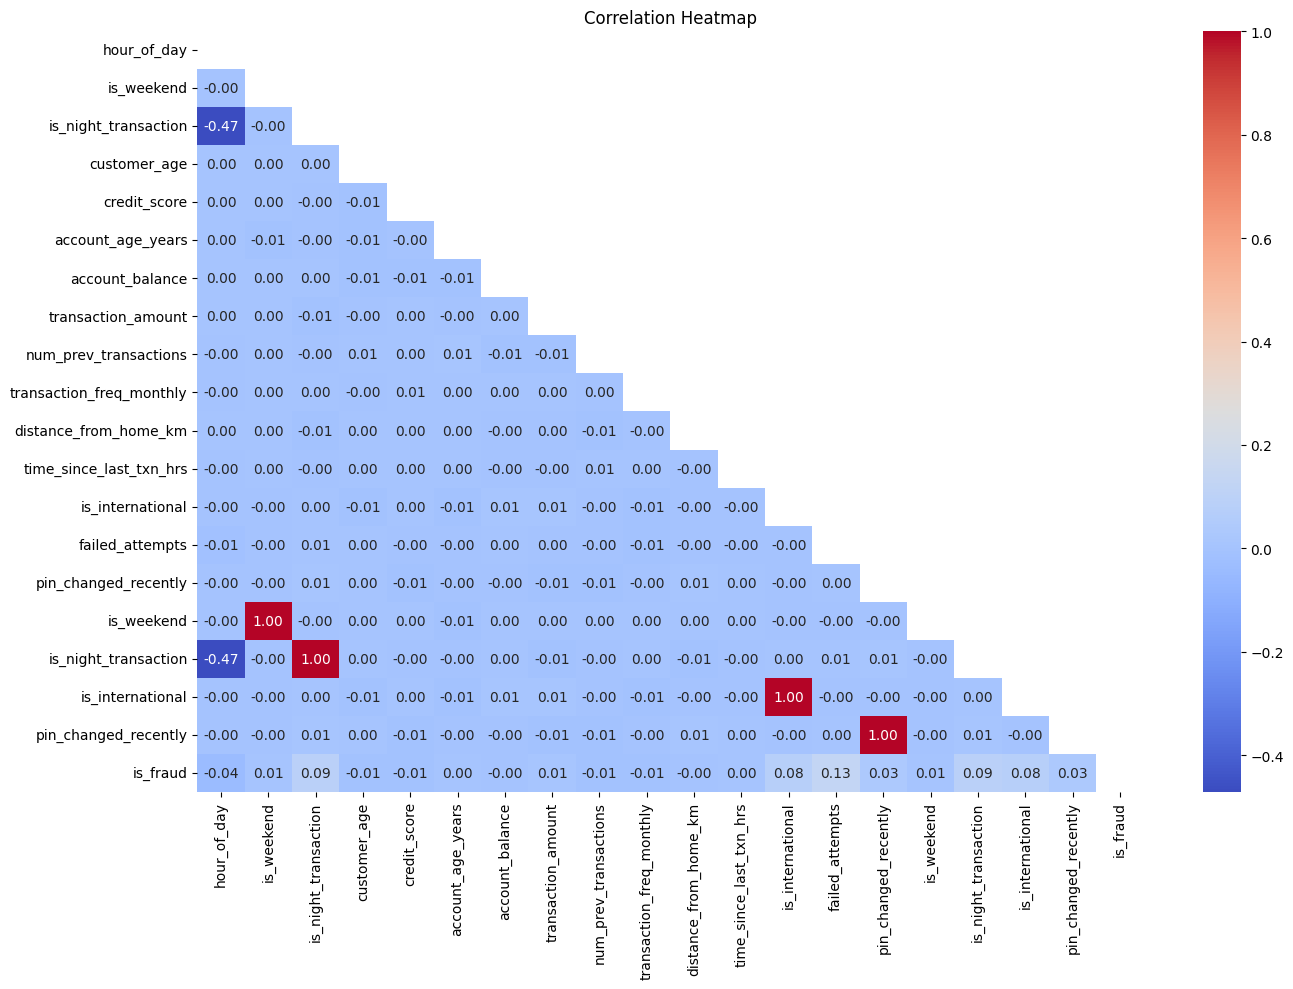

In [23]:
plt.figure(figsize=(14, 10))
corr = df[numeric_cols + binary_cols + ['is_fraud']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [24]:
grouped = df.groupby('is_fraud')[numeric_cols].mean().T
grouped.columns = ['Legitimate (0)', 'Fraud (1)']
grouped['Difference'] = grouped['Fraud (1)'] - grouped['Legitimate (0)']
grouped = grouped.sort_values('Difference', ascending=False)
print(grouped.round(3))

                          Legitimate (0)  Fraud (1)  Difference
transaction_amount               205.015    224.922      19.907
failed_attempts                    0.358      0.867       0.509
is_night_transaction               0.365      0.548       0.183
is_international                   0.143      0.267       0.125
time_since_last_txn_hrs           12.042     12.088       0.045
pin_changed_recently               0.077      0.116       0.039
is_weekend                         0.287      0.298       0.011
account_age_years                  4.927      4.935       0.009
distance_from_home_km             20.019     19.928      -0.091
transaction_freq_monthly          20.006     19.848      -0.157
customer_age                      41.751     41.368      -0.383
num_prev_transactions            149.992    149.536      -0.456
hour_of_day                       11.564     10.225      -1.338
credit_score                     679.571    676.798      -2.773
account_balance                16739.364

In [25]:
drop_dates = [c for c in date_cols if c in df.columns]
df = df.drop(columns=drop_dates)

In [26]:
high_card = ['city']
for col in high_card:
    if col in df.columns:
        freq_map = df[col].value_counts() / len(df)
        df[col + '_freq'] = df[col].map(freq_map)
        df = df.drop(columns=[col])
        print(f"Frequency encoded: {col}")

Frequency encoded: city


In [27]:
remaining_cat = [c for c in categorical_cols if c in df.columns]
df = pd.get_dummies(df, columns=remaining_cat, drop_first=True)
print(f"One-Hot encoded: {remaining_cat}")

One-Hot encoded: ['country', 'merchant_category', 'payment_method', 'device_type']


In [28]:
df = df.dropna(subset=['is_fraud'])

In [29]:
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [31]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
scaler = StandardScaler()

scale_cols = [c for c in numeric_cols if c in X_train.columns]
scale_cols += [c for c in X_train.columns if c.endswith('_freq')]

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])


In [32]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    random_state=42,
    C=1.0
)

model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [33]:
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_pred_prob)

print(f"Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

Accuracy  : 0.7147  (71.47%)
Precision : 0.1096
Recall    : 0.5745
F1 Score  : 0.1841
ROC-AUC   : 0.7164


In [35]:
from sklearn.metrics import classification_report
print(classification_report(
    y_test,
    y_pred,
    target_names=['Legitimate', 'Fraud']))

              precision    recall  f1-score   support

  Legitimate       0.97      0.72      0.83     10296
       Fraud       0.11      0.57      0.18       611

    accuracy                           0.71     10907
   macro avg       0.54      0.65      0.51     10907
weighted avg       0.92      0.71      0.79     10907



TN: 7444
FP 2852
FN: 260
TP: 351


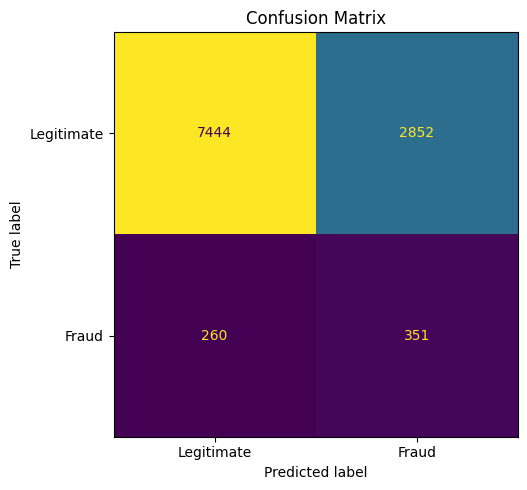

In [36]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

print(f'TN: {TN}')
print(f'FP {FP}')
print(f'FN: {FN}')
print(f'TP: {TP}')

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Legitimate', 'Fraud'])
disp.plot(ax=ax, colorbar=False)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

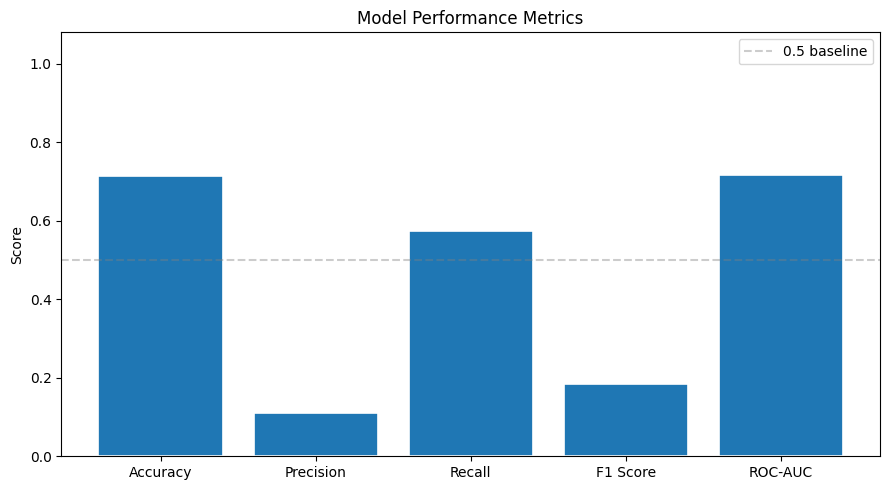

In [37]:
metrics = {
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1 Score': f1,
    'ROC-AUC': auc
}

plt.figure(figsize=(9, 5))
bars = plt.bar(metrics.keys(), metrics.values(),
               edgecolor='white', linewidth=1.2)
plt.ylim(0, 1.08)
plt.title('Model Performance Metrics')
plt.ylabel('Score')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4, label='0.5 baseline')
plt.legend()
plt.tight_layout()
plt.show()

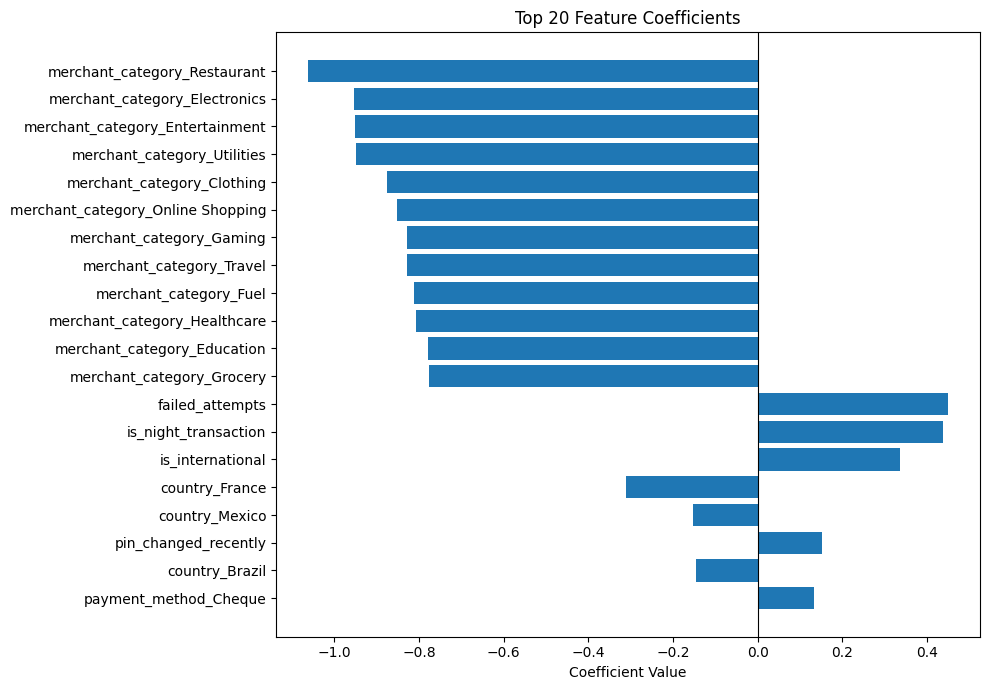

In [38]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(20)

plt.figure(figsize=(10, 7))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()